# COMI Presentation Materials Notebook

Run this notebook after the main comparison-training notebook. It regenerates presentation-friendly visuals without retraining the models.

In [1]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Google Colab drive mount skipped. Update the paths manually if needed.')

PROJECT_ROOT = Path('/content/drive/MyDrive/494_Project_test_3/comi_comparison_project')
DATASET_ROOT = Path('/content/drive/MyDrive/494_Project_test_3/COMI/dataset/BPAEC')
RESULTS_ROOT = PROJECT_ROOT / 'results'
MATERIALS_ROOT = RESULTS_ROOT / 'materials'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATASET_ROOT =', DATASET_ROOT)
print('MATERIALS_ROOT =', MATERIALS_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/494_Project_test_3/comi_comparison_project
DATASET_ROOT = /content/drive/MyDrive/494_Project_test_3/COMI/dataset/BPAEC
MATERIALS_ROOT = /content/drive/MyDrive/494_Project_test_3/comi_comparison_project/results/materials


In [2]:
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-q',
    '-r',
    str(PROJECT_ROOT / 'requirements_colab.txt'),
])

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

In [3]:
import pandas as pd
import torch
from IPython.display import display

from comi_pipeline import (
    CLASS_NAMES,
    RFConfig,
    build_flattened_image_features,
    build_model,
    build_model_richness_table,
    build_split_manifest,
    build_transforms,
    capture_feature_maps,
    create_dataloaders,
    denormalize_tensor,
    ensure_dir,
    extract_model_embeddings,
    load_pickle,
    plot_classwise_metric_comparison,
    plot_confusion_matrix_comparison,
    plot_decision_logic_comparison,
    plot_embedding_projection,
    plot_feature_map_grid,
    plot_gradcam_examples,
    plot_how_models_see_images,
    plot_model_comparison_chart,
    plot_pca_explained_variance,
    plot_pca_reconstructions,
    plot_pca_scatter,
    plot_pixel_to_vector_illustration,
    plot_preprocessing_panel,
    plot_probability_bars,
    plot_rf_decision_flow,
    plot_rf_featurization_panel,
    prepare_rf_data,
    resolve_device,
)

device = resolve_device()
ensure_dir(MATERIALS_ROOT)
for folder in ['random_forest_pca', 'baseline_cnn', 'resnet18', 'cross_model']:
    ensure_dir(MATERIALS_ROOT / folder)
print('Using device:', device)

Using device: cuda


In [4]:
manifest = build_split_manifest(DATASET_ROOT)
import json

rf_predictions = pd.read_csv(RESULTS_ROOT / 'random_forest_pca' / 'random_forest_test_predictions.csv')
baseline_predictions = pd.read_csv(RESULTS_ROOT / 'baseline_cnn' / 'baseline_test_predictions.csv')
resnet_predictions = pd.read_csv(RESULTS_ROOT / 'resnet18' / 'resnet18_test_predictions.csv')
rf_report = pd.read_csv(RESULTS_ROOT / 'random_forest_pca' / 'random_forest_test_classification_report.csv', index_col=0)
baseline_report = pd.read_csv(RESULTS_ROOT / 'baseline_cnn' / 'baseline_test_classification_report.csv', index_col=0)
resnet_report = pd.read_csv(RESULTS_ROOT / 'resnet18' / 'resnet18_test_classification_report.csv', index_col=0)
with open(RESULTS_ROOT / 'random_forest_pca' / 'random_forest_test_metrics.json', 'r', encoding='utf-8') as f:
    rf_metrics = json.load(f)
with open(RESULTS_ROOT / 'baseline_cnn' / 'baseline_test_metrics.json', 'r', encoding='utf-8') as f:
    baseline_metrics = json.load(f)
with open(RESULTS_ROOT / 'resnet18' / 'resnet18_test_metrics.json', 'r', encoding='utf-8') as f:
    resnet_metrics = json.load(f)
comparison = pd.read_csv(RESULTS_ROOT / 'model_comparison.csv')
display(comparison)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,random_forest_pca,0.959596,0.959363,0.959485,0.959279
1,baseline_cnn,0.767677,0.815290,0.765979,0.765195
2,resnet18,0.956229,0.958785,0.955533,0.955843


## Random Forest Materials

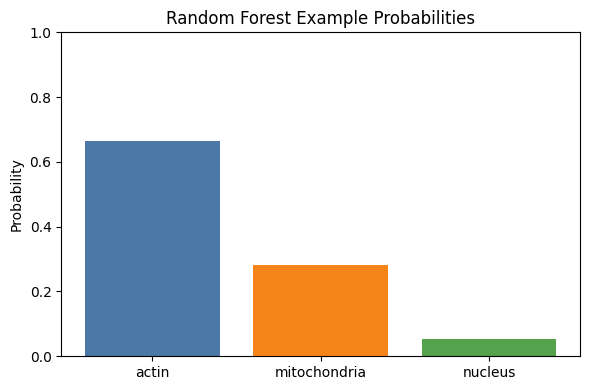

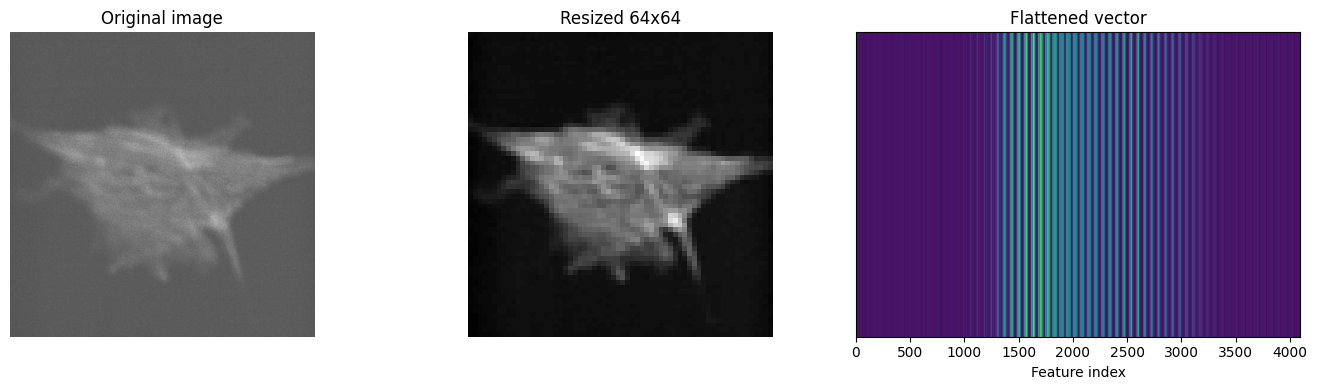

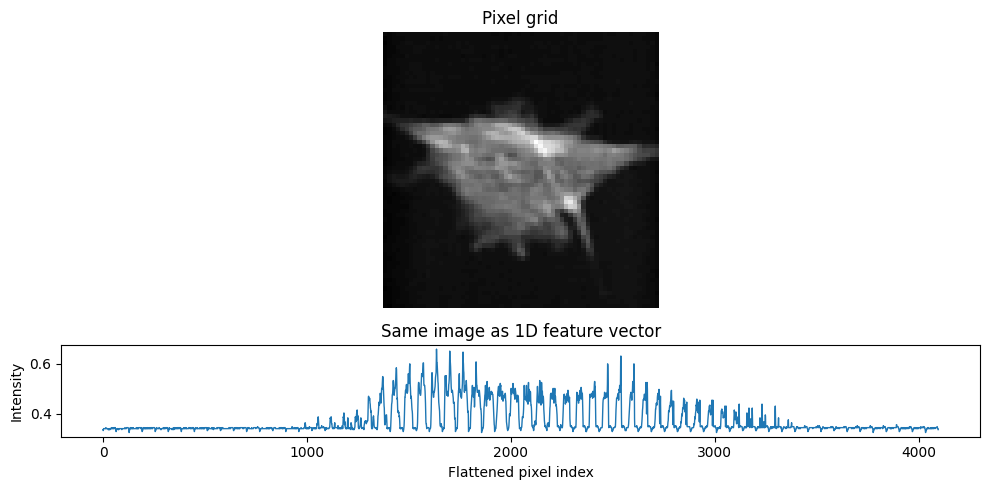

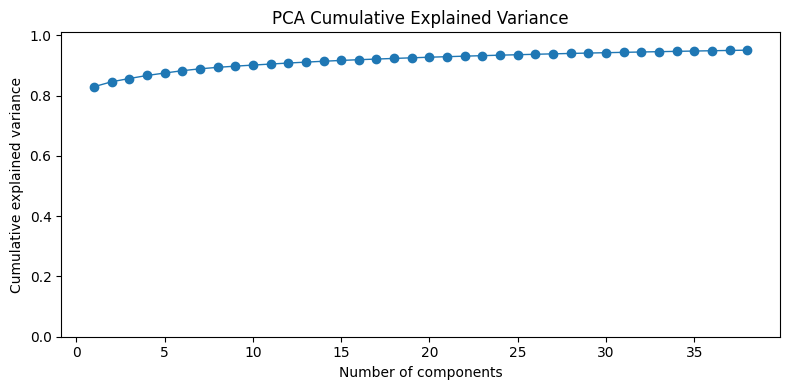

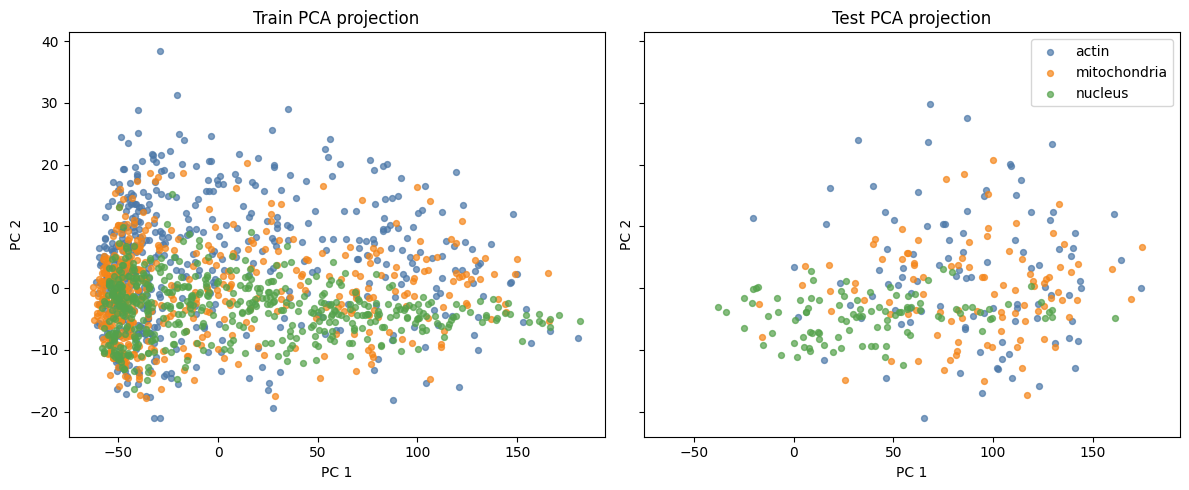

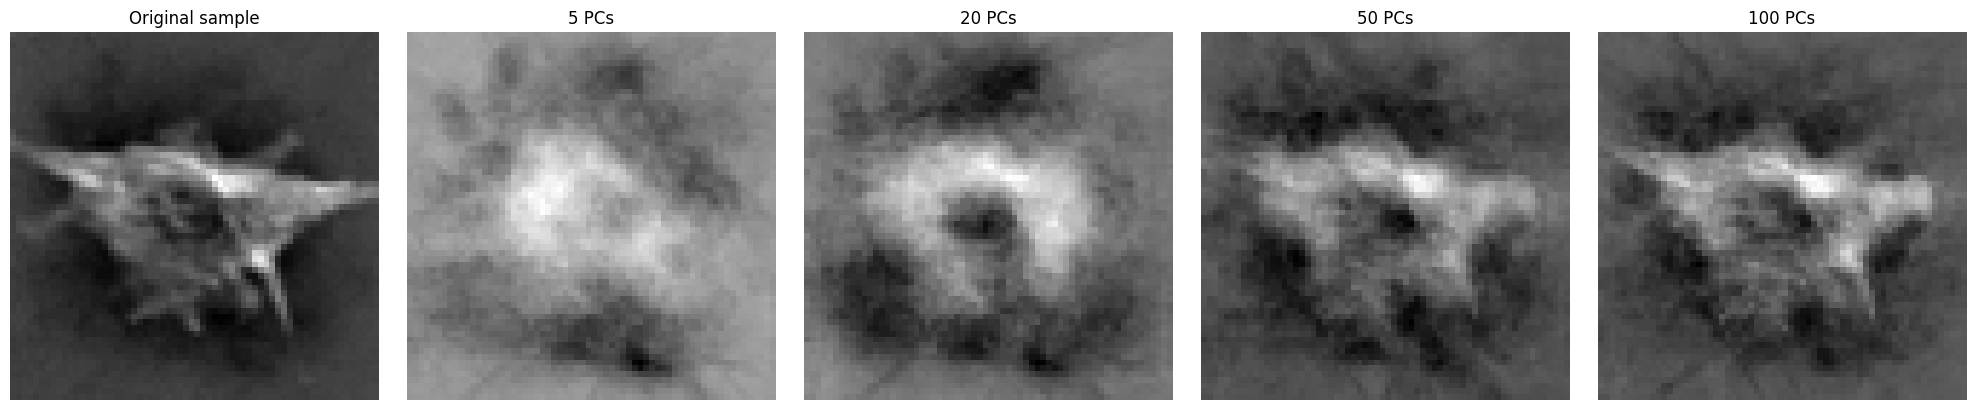

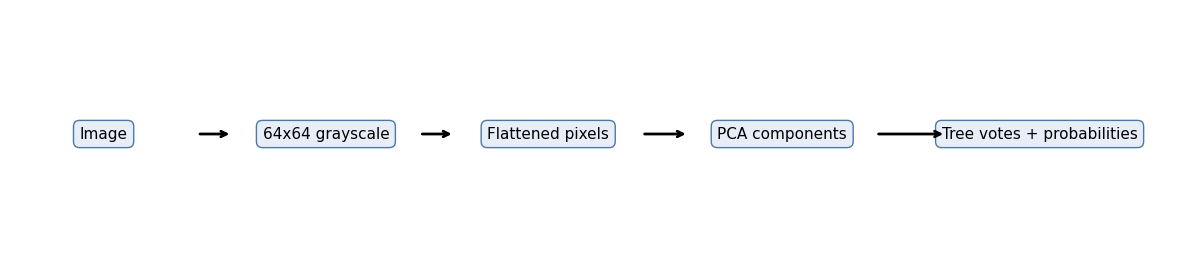

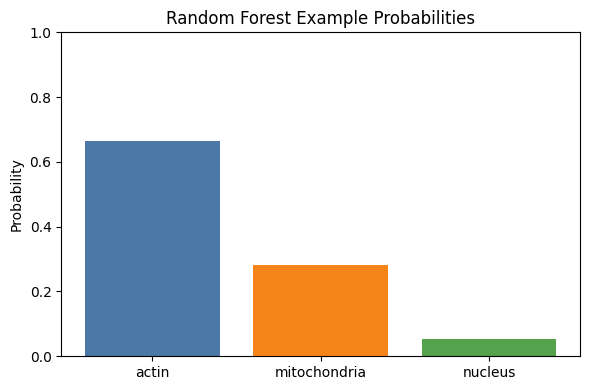

In [5]:
rf_config = RFConfig(image_size=64, pca_n_components=0.95, n_estimators=500, random_state=42, n_jobs=-1)
rf_data = prepare_rf_data(manifest, rf_config)
rf_model = load_pickle(RESULTS_ROOT / 'random_forest_pca' / 'random_forest_model.pkl')
rf_sample_path = rf_predictions.iloc[0]['path']
plot_rf_featurization_panel(rf_sample_path, image_size=64, output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_featurization_panel.png')
plot_pixel_to_vector_illustration(rf_sample_path, image_size=64, output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_pixel_to_vector.png')
plot_pca_explained_variance(rf_data['pca'], output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_pca_explained_variance.png')
plot_pca_scatter(rf_data['pca_features']['train'], rf_data['labels']['train'], rf_data['pca_features']['test'], rf_data['labels']['test'], output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_pca_scatter.png')
plot_pca_reconstructions(rf_data['scaled_features']['train'], rf_data['scaled_features']['test'][0], image_size=64, output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_pca_reconstructions.png')
plot_rf_decision_flow(output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_decision_flow.png')
plot_probability_bars(rf_predictions, sample_index=0, title='Random Forest Example Probabilities', output_path=MATERIALS_ROOT / 'random_forest_pca' / 'rf_probability_bars.png')

## Baseline CNN Materials

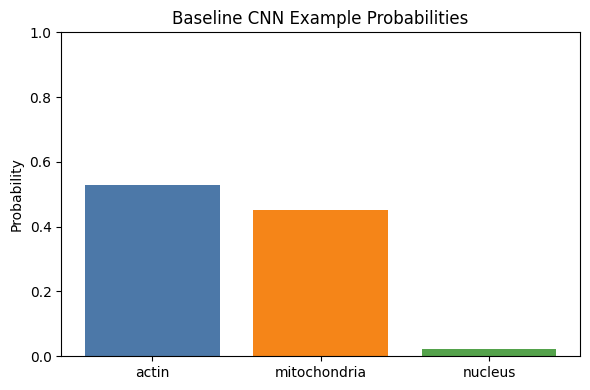

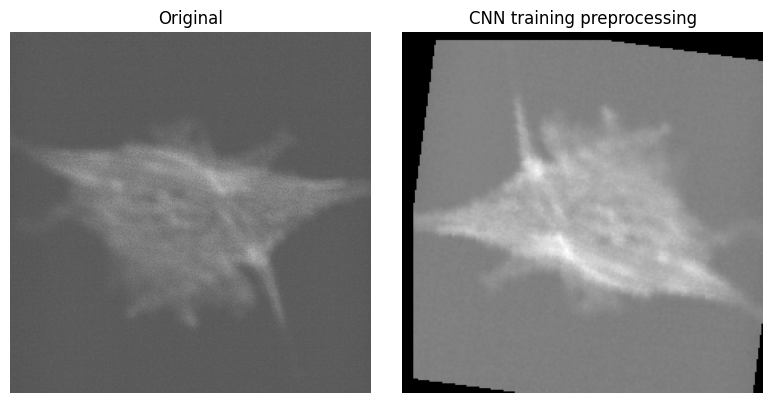

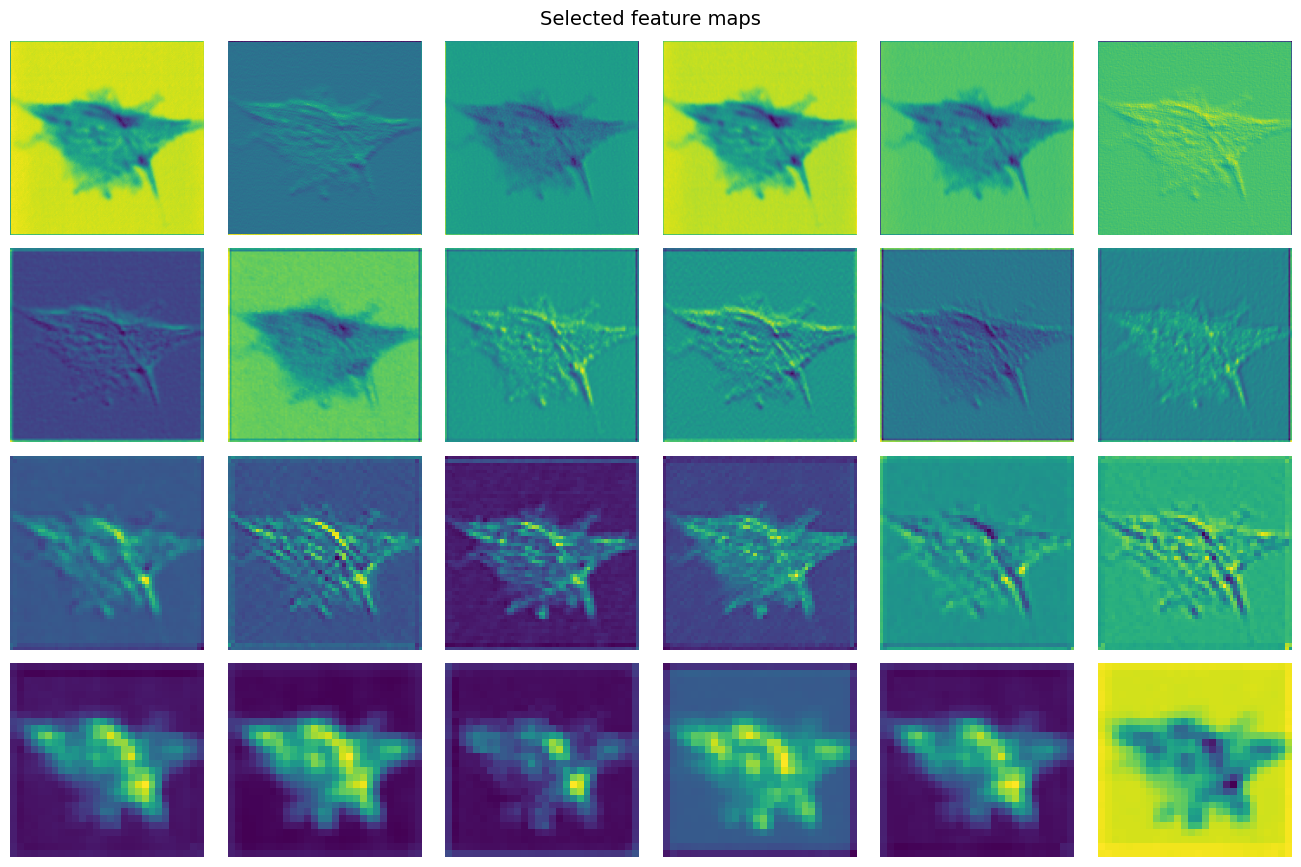

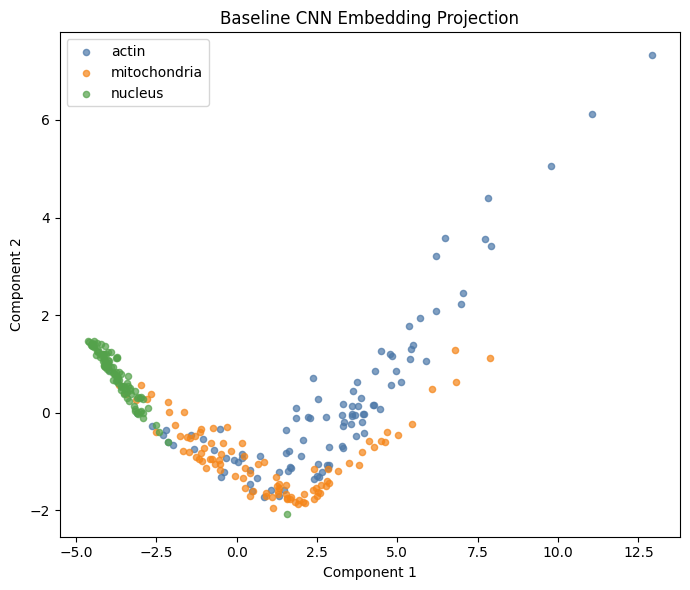

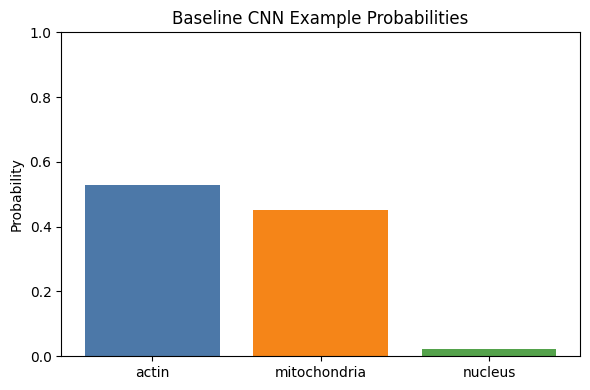

In [6]:
cnn_loaders, cnn_datasets, _ = create_dataloaders(manifest, image_size=224, batch_size=32, num_workers=2, normalize_mode='simple')
cnn_model = build_model('baseline_cnn', num_classes=len(CLASS_NAMES), pretrained=False)
cnn_model.load_state_dict(torch.load(RESULTS_ROOT / 'baseline_cnn' / 'baseline_cnn_best.pt', map_location=device))
cnn_model = cnn_model.to(device)
cnn_sample_path = baseline_predictions.iloc[0]['path']
plot_preprocessing_panel(cnn_sample_path, build_transforms(image_size=224, normalize_mode='simple')['train'], 'CNN training preprocessing', output_path=MATERIALS_ROOT / 'baseline_cnn' / 'cnn_preprocessing_panel.png')
sample = cnn_datasets['test'][0]
feature_maps = capture_feature_maps(cnn_model, sample['image'].unsqueeze(0), 'baseline_cnn', device=device)
plot_feature_map_grid(feature_maps, output_path=MATERIALS_ROOT / 'baseline_cnn' / 'cnn_feature_maps.png')
cnn_embeddings = extract_model_embeddings(cnn_model, cnn_loaders['test'], 'baseline_cnn', device=device)
cnn_embeddings.to_csv(MATERIALS_ROOT / 'baseline_cnn' / 'cnn_embeddings.csv', index=False)
plot_embedding_projection(cnn_embeddings, 'Baseline CNN Embedding Projection', output_path=MATERIALS_ROOT / 'baseline_cnn' / 'cnn_embedding_projection.png')
plot_probability_bars(baseline_predictions, sample_index=0, title='Baseline CNN Example Probabilities', output_path=MATERIALS_ROOT / 'baseline_cnn' / 'cnn_probability_bars.png')

## ResNet18 Materials

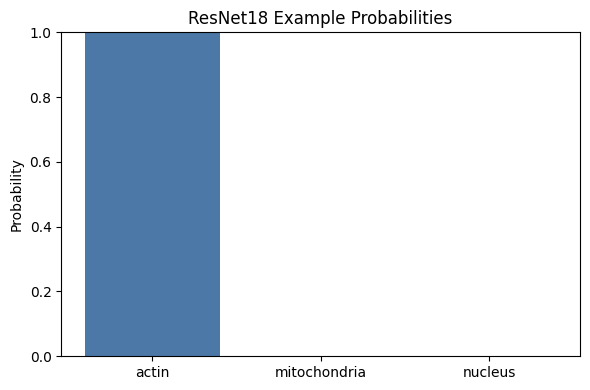

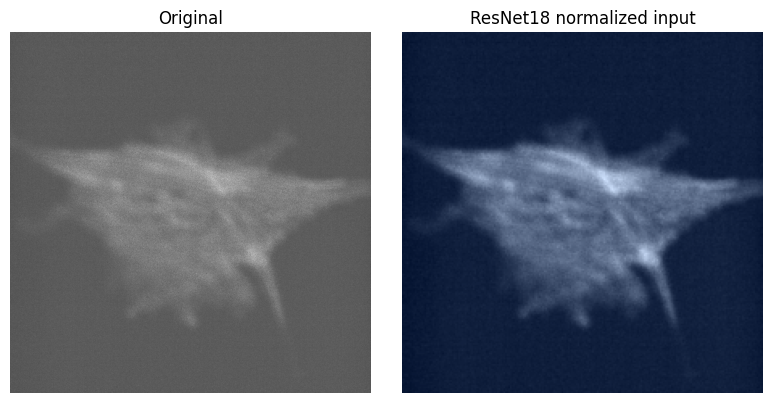

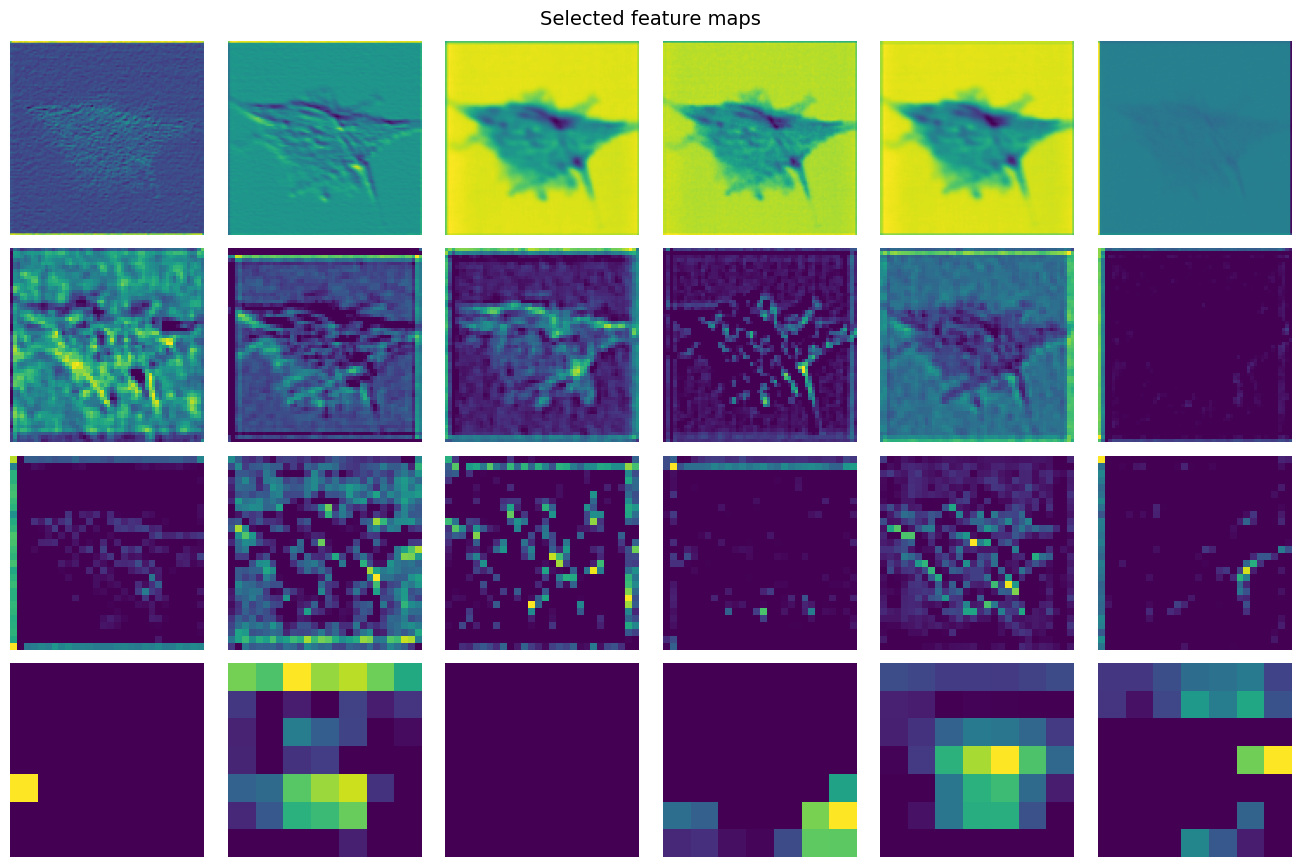

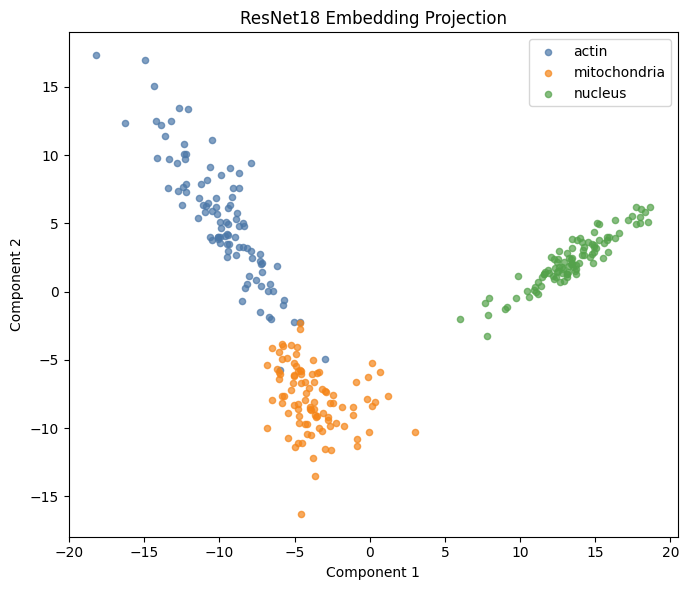

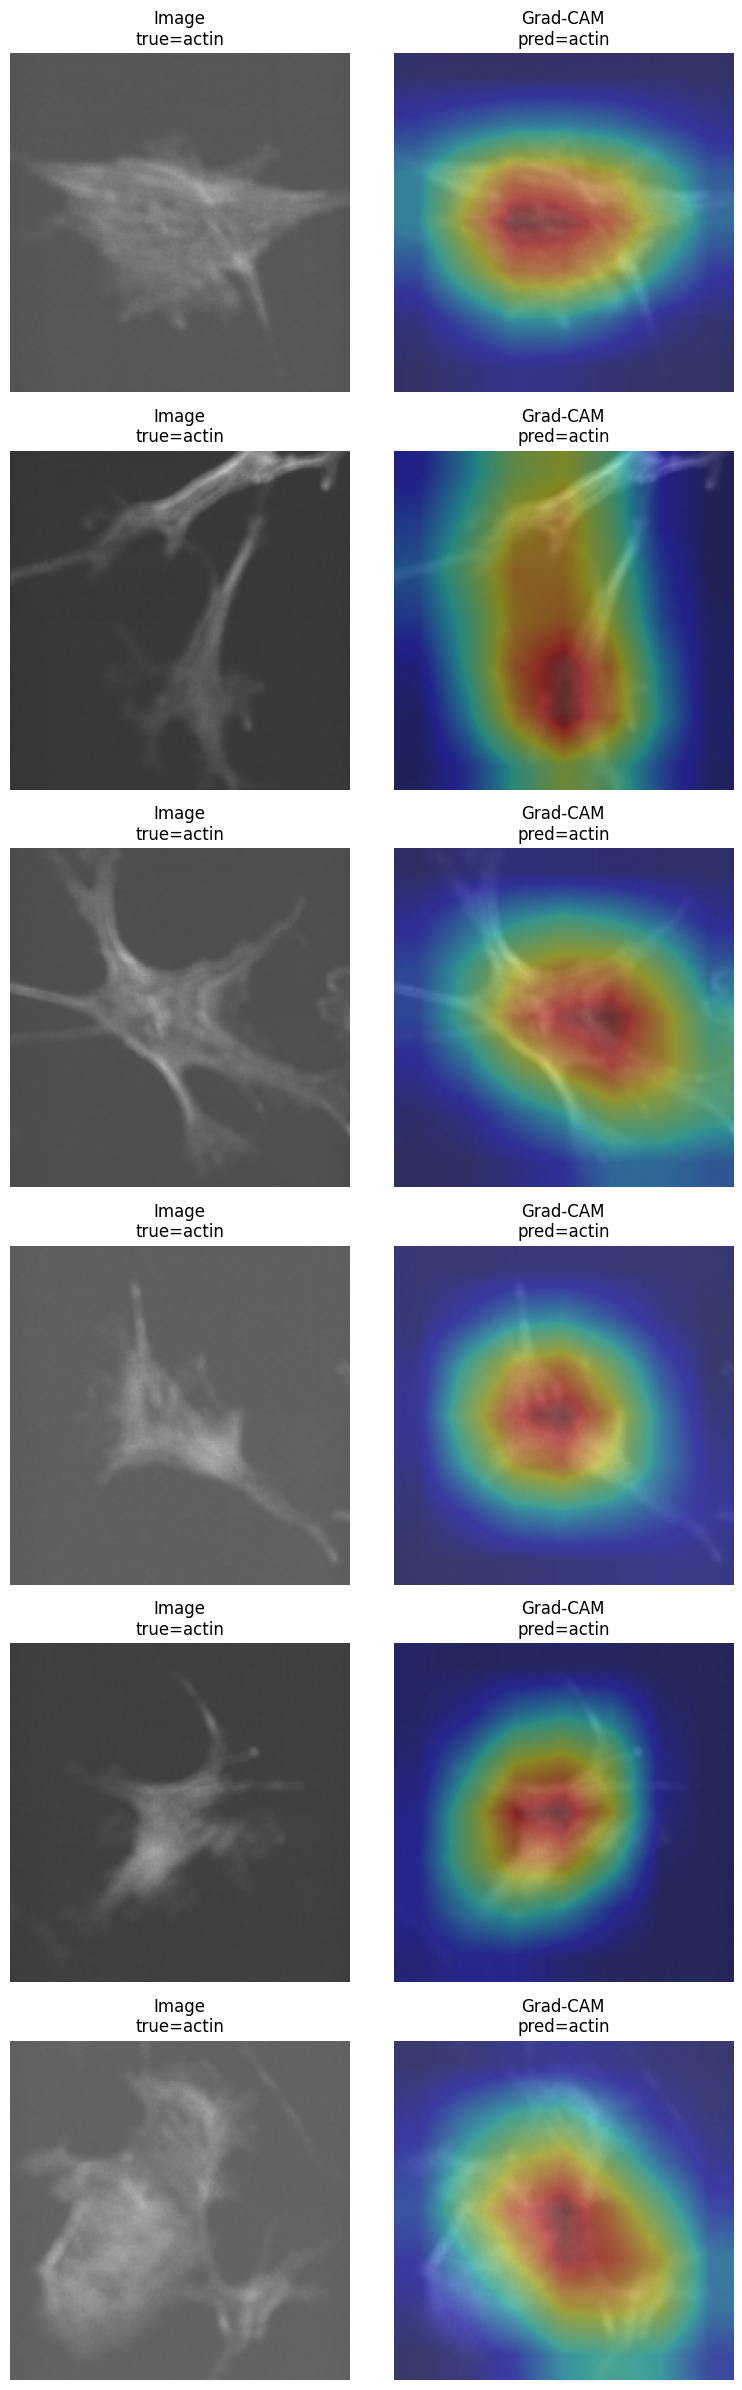

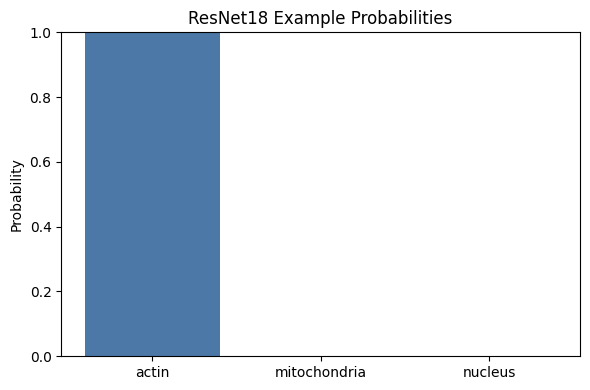

In [7]:
resnet_loaders, resnet_datasets, _ = create_dataloaders(manifest, image_size=224, batch_size=32, num_workers=2, normalize_mode='imagenet')
resnet_model = build_model('resnet18', num_classes=len(CLASS_NAMES), pretrained=False)
resnet_model.load_state_dict(torch.load(RESULTS_ROOT / 'resnet18' / 'resnet18_best.pt', map_location=device))
resnet_model = resnet_model.to(device)
resnet_sample_path = resnet_predictions.iloc[0]['path']
plot_preprocessing_panel(resnet_sample_path, build_transforms(image_size=224, normalize_mode='imagenet')['test'], 'ResNet18 normalized input', output_path=MATERIALS_ROOT / 'resnet18' / 'resnet_preprocessing_panel.png')
resnet_sample = resnet_datasets['test'][0]
resnet_feature_maps = capture_feature_maps(resnet_model, resnet_sample['image'].unsqueeze(0), 'resnet18', device=device)
plot_feature_map_grid(resnet_feature_maps, output_path=MATERIALS_ROOT / 'resnet18' / 'resnet_feature_maps.png')
resnet_embeddings = extract_model_embeddings(resnet_model, resnet_loaders['test'], 'resnet18', device=device)
resnet_embeddings.to_csv(MATERIALS_ROOT / 'resnet18' / 'resnet_embeddings.csv', index=False)
plot_embedding_projection(resnet_embeddings, 'ResNet18 Embedding Projection', output_path=MATERIALS_ROOT / 'resnet18' / 'resnet_embedding_projection.png')
gradcam_candidates = resnet_predictions.loc[resnet_predictions['is_correct']].head(6).copy()
if gradcam_candidates.empty:
    gradcam_candidates = resnet_predictions.head(6).copy()
plot_gradcam_examples(resnet_model, resnet_datasets['test'], gradcam_candidates, output_path=MATERIALS_ROOT / 'resnet18' / 'resnet_gradcam_examples.png', device=device, normalize_mode='imagenet', max_examples=6)
plot_probability_bars(resnet_predictions, sample_index=0, title='ResNet18 Example Probabilities', output_path=MATERIALS_ROOT / 'resnet18' / 'resnet_probability_bars.png')

## Cross-Model Educational Assets

/content/drive/MyDrive/494_Project_test_3/comi_comparison_project/src/comi_pipeline.py:1521: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


,model,feature_style,spatial_learning,expected_strength
0,random_forest_pca,flattened pixels + PCA,no,classical baseline
1,baseline_cnn,learned convolutional features,yes,moderate deep-learning baseline
2,resnet18,pretrained deep hierarchical features,yes,strongest expected model


Presentation-material generation complete.


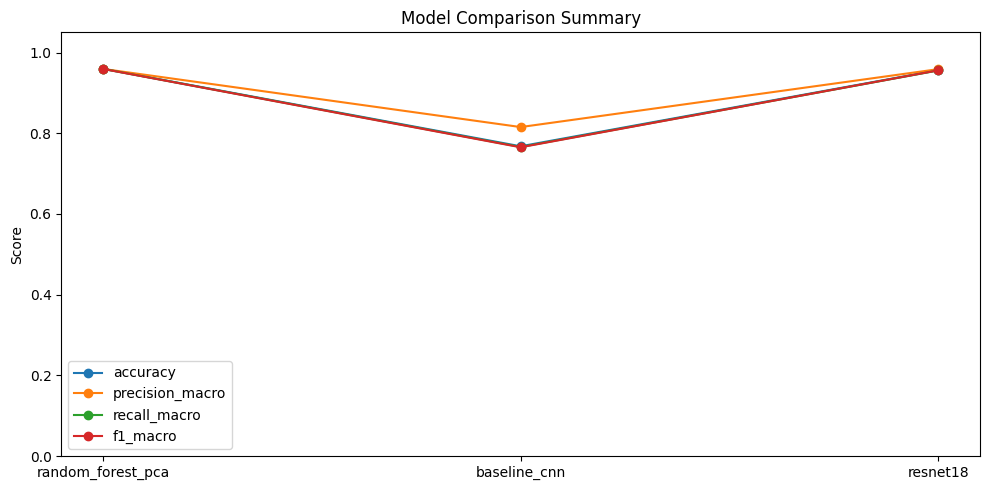

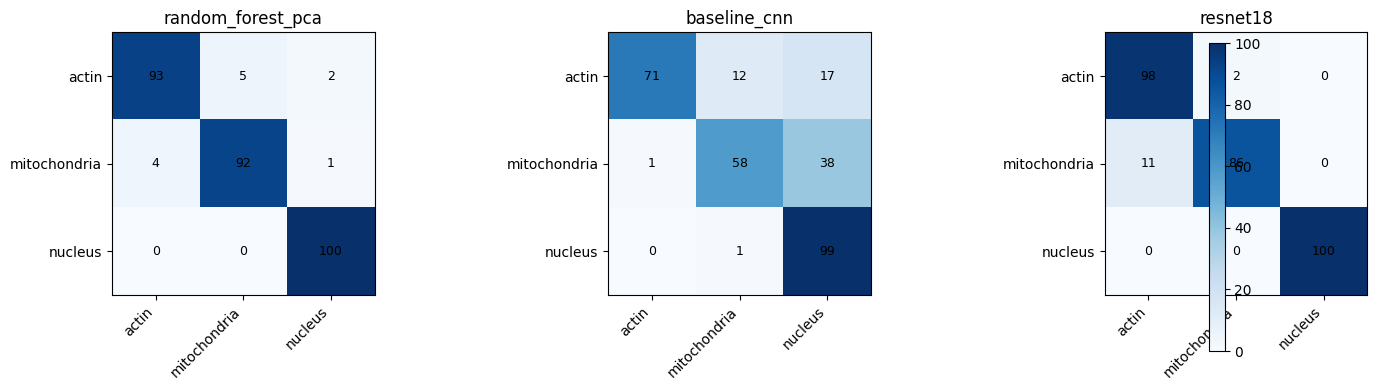

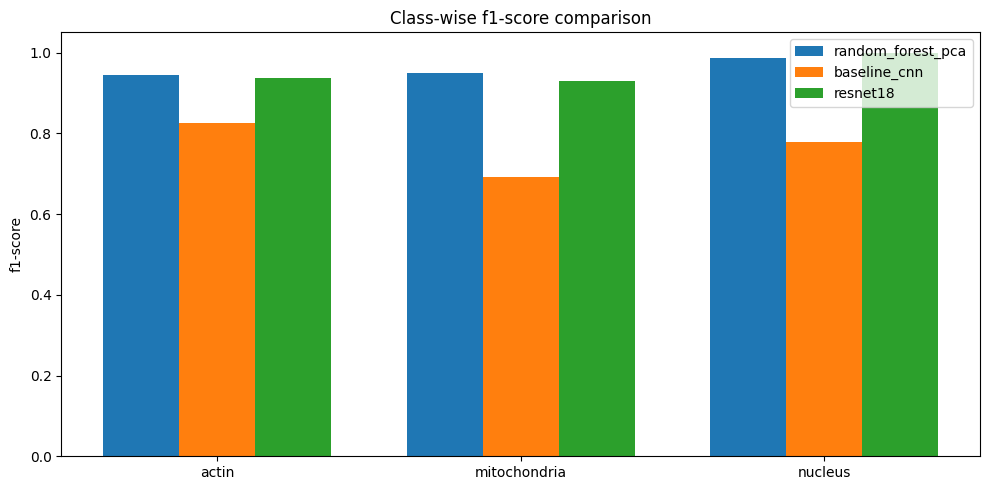

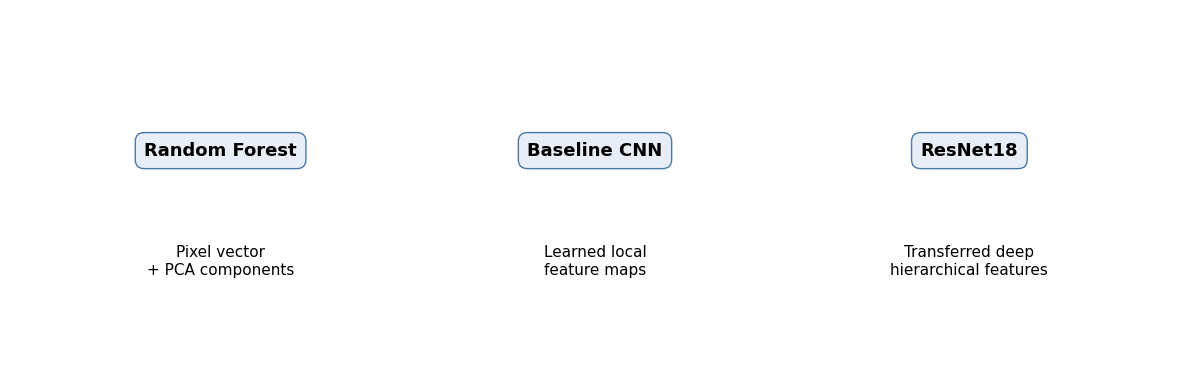

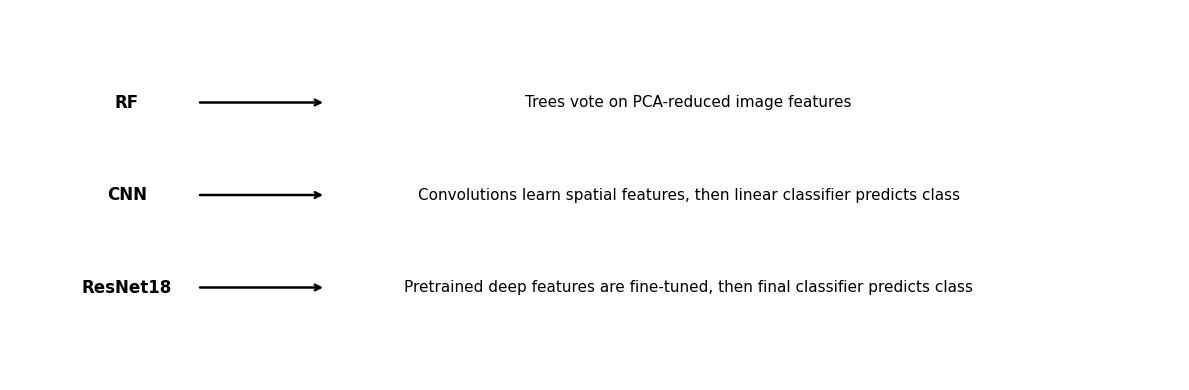

In [8]:
plot_model_comparison_chart(comparison, MATERIALS_ROOT / 'cross_model' / 'model_comparison_chart.png')
plot_confusion_matrix_comparison({'random_forest_pca': rf_metrics, 'baseline_cnn': baseline_metrics, 'resnet18': resnet_metrics}, output_path=MATERIALS_ROOT / 'cross_model' / 'confusion_matrix_comparison.png')
plot_classwise_metric_comparison({'random_forest_pca': rf_report, 'baseline_cnn': baseline_report, 'resnet18': resnet_report}, metric_name='f1-score', output_path=MATERIALS_ROOT / 'cross_model' / 'classwise_f1_comparison.png')
plot_how_models_see_images(output_path=MATERIALS_ROOT / 'cross_model' / 'how_models_see_images.png')
plot_decision_logic_comparison(output_path=MATERIALS_ROOT / 'cross_model' / 'decision_logic_comparison.png')
richness = build_model_richness_table()
richness.to_csv(MATERIALS_ROOT / 'cross_model' / 'model_richness_table.csv', index=False)
display(richness)
print('Presentation-material generation complete.')